In [11]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPooling2D, Conv2D

In [12]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

In [13]:
train_images.shape

(50000, 32, 32, 3)

In [14]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [15]:
# DO NOT convert to one-hot
# train_labels remains integers

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))  # No activation needed

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(train_images, train_labels, epochs=20,
                    validation_split=0.1, batch_size=128)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 56s 154ms/step - accuracy: 0.4104 - loss: 1.6222 - val_accuracy: 0.4808 - val_loss: 1.4596
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 80s 150ms/step - accuracy: 0.5466 - loss: 1.2670 - val_accuracy: 0.5646 - val_loss: 1.2220
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.6049 - loss: 1.1228 - val_accuracy: 0.6224 - val_loss: 1.0523
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 54s 152ms/step - accuracy: 0.6399 - loss: 1.0269 - val_accuracy: 0.6662 - val_loss: 0.9626
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 81s 151ms/step - accuracy: 0.6655 - loss: 0.9505 - val_accuracy: 0.6714 - val_loss: 0.9664
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.6847 - loss: 0.9015 - val_accuracy: 0.6806 - val_loss: 0.9135
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.7023 - loss: 0.8508 - val_accuracy: 0.6972 - val_loss: 0.8735
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.7209 - loss: 0

313/313 - 6s - 19ms/step - accuracy: 0.7162 - loss: 0.9131


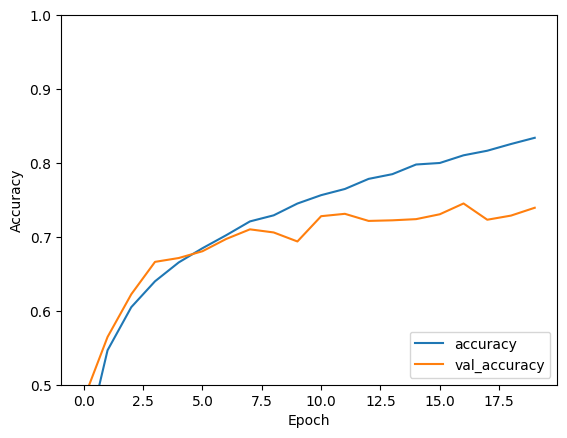

In [18]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

In [19]:
print(test_acc)

0.7161999940872192
